# Radiación de Cuerpo Negro y Espectros Estelares

**Objetivo general**

Implementar una simulación del espectro de radiación de cuerpo negro, basada en el modelo de gas de fotones y la distribución de bose–einstein, para estudiar a través de la temperatura superficial de las estrellas, usando una estimación de distancia

***Puntos principales***

- implementamos la ley de planck para un gas de fotones.
- comparamos espectros de varias estrellas tipo.
- ajustamos la temperatura de una estrella a partir de un “espectro observado” sintético.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# constantes físicas en si
h = 6.62607015e-34      # j s
c = 2.99792458e8        # m/s
kb = 1.380649e-23       # j/k
sigma = 5.670374419e-8  # w m^-2 k^-4
b_wien = 2.897771955e-3 # m k

## Gas de fotones --> Ley de Planck

para un gas de fotones en equilibrio térmico:

- los fotones son bosones, con ocupación media de bose–einstein
  
     $\bar{n}(\nu, t) = \frac{1}{\exp\left(\frac{h \nu}{k_b t}\right) - 1}$

  y potencial químico $μ = 0$
  
- combinando $\bar{n}$ con la densidad de estados electromagnéticos se obtiene la ley de planck en función de la longitud de onda

  $ b_\lambda(\lambda, t) =
  \frac{2 h c^2}{\lambda^5}
  \frac{1}{\exp\left(\frac{h c}{\lambda k_b t}\right) - 1}$

  implementamos directamente esta expresión.


In [ ]:
def planck_lambda(lamb, t):
    """
    ley de planck en función de la longitud de onda.

    lamb : longitud de onda [m]
    t    : temperatura [k]

    devuelve b_lambda(λ, t) en [w m^-3 sr^-1].
    """
    lamb = np.array(lamb, dtype=float)
    a = 2 * h * c**2 / lamb**5
    expo = h * c / (lamb * kb * t)
    return a / (np.exp(expo) - 1.0)

def wien_lambda_max(t):
    return b_wien / t

def stefan_boltzmann_flux(t):
    return sigma * t**4

def luminosidad_cuerpo_negro(t, r):
    return 4 * np.pi * r**2 * stefan_boltzmann_flux(t)

def flujo_observado(l, d):
    return l / (4 * np.pi * d**2)


In [ ]:
def espectro_cuerpo_negro(t, lambda_min_nm=100, lambda_max_nm=3000, n_puntos=1000):
    lambda_nm = np.linspace(lambda_min_nm, lambda_max_nm, n_puntos)
    lambda_m = lambda_nm * 1e-9
    b_lambda = planck_lambda(lambda_m, t)
    return lambda_nm, b_lambda

def comparar_estrellas(temperaturas, etiquetas=None,
                       lambda_min_nm=100, lambda_max_nm=3000):
    plt.figure(figsize=(7, 5))

    for i, t in enumerate(temperaturas):
        lambda_nm, b_lambda = espectro_cuerpo_negro(t, lambda_min_nm, lambda_max_nm)
        if etiquetas is None:
            lab = f"t = {t} k"
        else:
            lab = f"{etiquetas[i]} (t ≈ {t} k)"
        plt.plot(lambda_nm, b_lambda, label=lab)

    plt.xlabel("longitud de onda [nm]")
    plt.ylabel(r"radiancia espectral $B_\lambda$ [w m$^{-3}$ sr$^{-1}$]")
    plt.title("espectros de cuerpo negro para distintas temperaturas")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


## Ejemplo: Comparación de estrellas

Probamos con tres temperaturas típicas:

- Estrella fría tipo k: t ≈ 4500 k
- Sol: t ≈ 5800 k
- Estrella caliente tipo b: t ≈ 10000 k

esto ilustra cómo el máximo del espectro se desplaza hacia longitudes de onda más cortas al aumentar la temperatura (ley de wien) y cómo crece la intensidad total (ley de stefan–boltzmann).


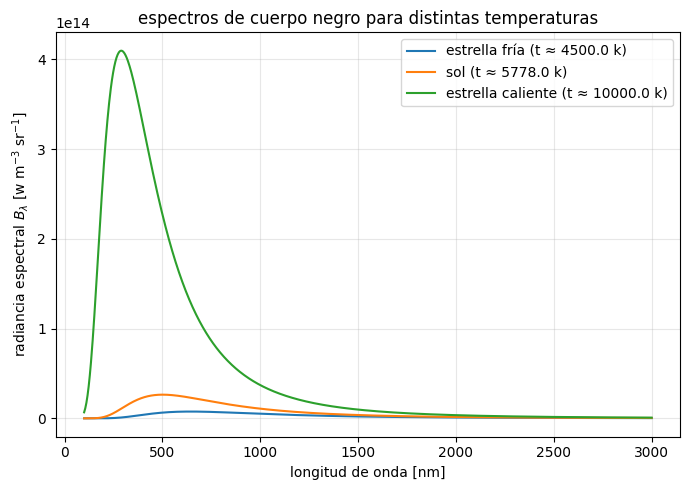

In [ ]:
t_frio = 4500.0
t_sol = 5778.0
t_caliente = 10000.0

temperaturas = [t_frio, t_sol, t_caliente]
etiquetas = ["estrella fría", "sol", "estrella caliente"]

comparar_estrellas(temperaturas, etiquetas)

## Ajuste de temperatura a partir de un espectro sintético

¿qué hacemos?

1. generamos un “espectro observado” sintético como cuerpo negro a temperatura $t_{\text{real}}$
2. añadimos ruido gaussiano para simular incertidumbre de medición.
3. ajustamos la temperatura usando mínimos cuadrados, comparando los datos con la ley de planck.

esto imita el proceso de estimar la temperatura superficial de una estrella real a partir de su espectro continuo

In [ ]:
rng = np.random.default_rng(seed=123)

def generar_espectro_sintetico(t_real, ruido_relativo=0.05,
                               lambda_min_nm=300, lambda_max_nm=1200,
                               n_puntos=200):
    lambda_nm = np.linspace(lambda_min_nm, lambda_max_nm, n_puntos)
    lambda_m = lambda_nm * 1e-9
    señal = planck_lambda(lambda_m, t_real)
    ruido = ruido_relativo * señal * rng.normal(size=señal.shape)
    datos = señal + ruido
    return lambda_nm, datos

def modelo_ajuste(lambda_nm, t, a):
    """
    modelo para el ajuste:
    datos(λ) ≈ a * b_lambda(λ, t)
    el factor a --> área efectiva
    """
    lambda_m = lambda_nm * 1e-9
    return a * planck_lambda(lambda_m, t)

def ajustar_temperatura(lambda_nm, datos, t_inicial=6000.0, a_inicial=1.0):
    p0 = [t_inicial, a_inicial]
    popt, pcov = curve_fit(modelo_ajuste, lambda_nm, datos, p0=p0, maxfev=10000)
    t_fit, a_fit = popt
    return t_fit, a_fit, pcov

def demo_ajuste_temperatura(t_real=6500.0):
    lambda_nm, datos = generar_espectro_sintetico(t_real)
    t_fit, a_fit, pcov = ajustar_temperatura(lambda_nm, datos)

    lambda_fino = np.linspace(lambda_nm.min(), lambda_nm.max(), 1000)
    ajuste = modelo_ajuste(lambda_fino, t_fit, a_fit)

    plt.figure(figsize=(7, 5))
    plt.scatter(lambda_nm, datos, s=15, color="k", alpha=0.7,
                label="Datos sintéticos")
    plt.plot(lambda_fino, ajuste, color="green",
             label=f"Ajuste planck (t_fit ≈ {t_fit} k)")
    plt.xlabel("Longitud de Onda [nm]")
    plt.ylabel("Intensidad (unidades arbitrarias)")
    plt.title("Ajuste de Temperatura a partir de un Espectro Sintético")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"temperatura real      t_real = {t_real} k")
    print(f"temperatura ajustada  t_fit  = {t_fit} k")

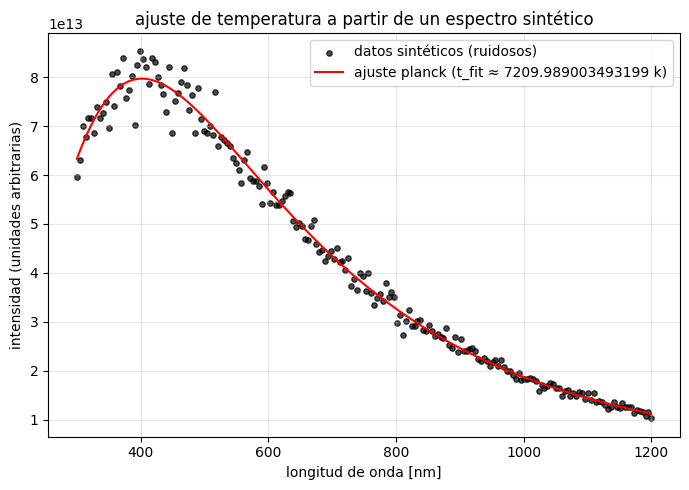

temperatura real      t_real = 7200.0 k
temperatura ajustada  t_fit  = 7209.989003493199 k


In [ ]:
demo_ajuste_temperatura(t_real=7200.0)